In [63]:
# --- Importaciones de bibliotecas estándar ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Importaciones de nuestro paquete local ---
# Añadimos la ruta al directorio padre para que Python encuentre la carpeta 'src'
import sys
sys.path.append('../')

from src.ofdm_tf import transmisor as transmisor
from src.ofdm_tf import receptor as receptor
from src.ofdm_tf import params as p
from src.ofdm_tf import utils
from src.ofdm_tf import mapping as mp
from src.ofdm_tf import channel as ch 
from src.ofdm_tf import demapping as dmp
from src.ofdm_tf import synchronization as sync
from scipy.special import erfc

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
print("--- Entorno listo ---")

--- Entorno listo ---


In [64]:
# --- Bloque 0.1: Panel de Control de la Simulación ---

# Modifica estos parámetros para cambiar el comportamiento de todo el notebook.

# MODO_CANAL: Define el tipo de canal a utilizar.
# Opciones: "ideal", "awgn", "multitap_awgn", "multitap_eq"
MODO_CANAL = "ideal"

# EBN0_DB: Define el nivel de Eb/N0 en dB.
# Se usa SOLO si MODO_CANAL es "awgn".
# Para una sola ejecución
# Para la curva BER, este valor se ignorará y se usará el del bucle.
EBN0_DB_SINGLE_RUN = 3 

print("--- Configuración de la Simulación ---")
print(f"Modo del Canal: {MODO_CANAL}")
if MODO_CANAL == "awgn":
    print(f"Eb/N0 para ejecución única: {EBN0_DB_SINGLE_RUN} dB")
print("-------------------------------------")

--- Configuración de la Simulación ---
Modo del Canal: ideal
-------------------------------------


Modo sin pilotos: generando bits para todas las subportadoras activas.
Parámetros de la simulación:
  - Símbolos OFDM a simular (N_sym): 8
  - Subportadoras de datos por símbolo (K): 8
  - Bits por símbolo de constelación (mu): 2
--------------------------------------------------
Total de bits a generar: 128

Dimensión del vector de bits generado: (128,)
Primeros 20 bits generados: [1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0]


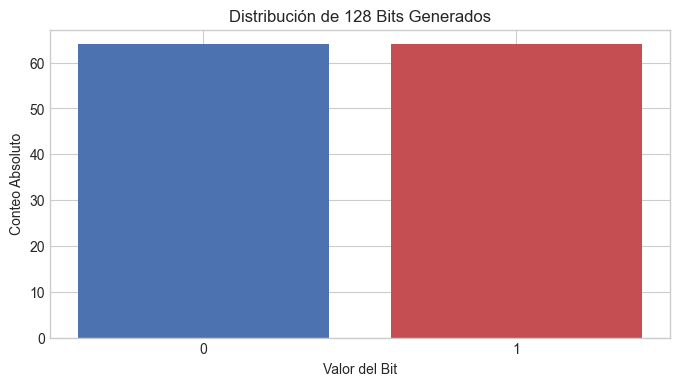


Media de los bits: 0.5000 (valor ideal: 0.5)


In [65]:
use_pilots_and_eq = (MODO_CANAL == "multitap_eq")

# Generar la cantidad correcta de bits según el modo
if use_pilots_and_eq:
    print("Modo con pilotos: generando bits solo para las subportadoras de datos.")
    bits_tx = transmisor.generate_data_bits(p.N_sym)
    num_carriers_for_bits = p.K_DATA
else:
    print("Modo sin pilotos: generando bits para todas las subportadoras activas.")
    bits_tx = transmisor.generate_all_bits(p.N_sym)
    num_carriers_for_bits = p.K_TOTAL

n_total_bits = len(bits_tx) # Obtenemos la longitud del resultado

print(f"Parámetros de la simulación:")
print(f"  - Símbolos OFDM a simular (N_sym): {p.N_sym}")
print(f"  - Subportadoras de datos por símbolo (K): {num_carriers_for_bits}")
print(f"  - Bits por símbolo de constelación (mu): {p.mu}")
print(f"--------------------------------------------------")    
print(f"Total de bits a generar: {n_total_bits}")

# --- Verificación ---
print(f"\nDimensión del vector de bits generado: {bits_tx.shape}")
print(f"Primeros 20 bits generados: {bits_tx[:20]}")

# Comprobar que la distribución es aproximadamente uniforme
plt.figure(figsize=(8, 4))
counts = np.bincount(bits_tx)
plt.bar([0, 1], counts, color=['#4c72b0', '#c44e52'])
plt.title(f'Distribución de {n_total_bits} Bits Generados')
plt.xticks([0, 1])
plt.xlabel('Valor del Bit')
plt.ylabel('Conteo Absoluto')
plt.show()

media_bits = np.mean(bits_tx)
print(f"\nMedia de los bits: {media_bits:.4f} (valor ideal: 0.5)")
assert 0.49 < media_bits < 0.51, "La distribución de bits no parece uniforme."

In [66]:
ak_symbols_flat = transmisor.map_bits_to_symbols(bits_tx)

# Mapear cada par de bits (b1, b2) a un símbolo QPSK con Gray mapping
# bits_reshaped tiene forma (n_símbolos, 2): columna 0 = b1 (MSB), columna 1 = b2 (LSB)
# Con Gray mapping:
#   (b1,b2) = (1,0) →  +1 – j
#   (b1,b2) = (1,1) →  –1 – j
#   (b1,b2) = (0,1) →  –1 + j
#   (b1,b2) = (0,0) →  +1 + j
# Fómula eficiente: real = 1–2·b2, imag = 1–2·b1, luego normalizamos por √2

# --- Verificación ---
print(f"Dimensiones de la matriz de bits agrupados: {ak_symbols_flat.shape}")
print("\nPrimeros 5 símbolos a_k generados (redondeados):")
print(np.round(ak_symbols_flat[:5], 3))

Dimensiones de la matriz de bits agrupados: (64,)

Primeros 5 símbolos a_k generados (redondeados):
[ 0.707-0.707j -0.707+0.707j  0.707-0.707j -0.707+0.707j -0.707-0.707j]


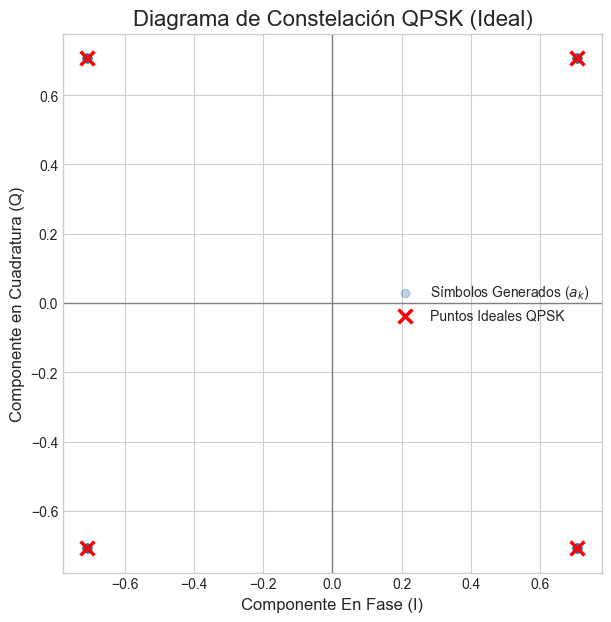

In [67]:
# Crear un scatter plot de la constelación ideal
# Estos son los 4 puntos que deberían existir
bits_b1 = np.array([0, 0, 1, 1])  # Primera columna de la tabla (los b₁)
bits_b2 = np.array([0, 1, 1, 0])  # Segunda columna de la tabla (los b₂)

ideal_constellation = ( (1 - 2*bits_b2) + 1j*(1 - 2*bits_b1) ) / np.sqrt(2)
# if 0 => +1
# if 1 => -1

plt.figure(figsize=(7, 7))

# Graficamos una muestra de los símbolos generados para no sobrecargar el gráfico
# Usamos alpha para ver la densidad de puntos
plt.scatter(np.real(ak_symbols_flat[:5000]), np.imag(ak_symbols_flat[:5000]), 
            alpha=0.3, label='Símbolos Generados ($a_k$)')

# Superponemos los puntos ideales para verificar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Diagrama de Constelación QPSK (Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)', fontsize=12)
plt.ylabel('Componente en Cuadratura (Q)', fontsize=12)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square')
plt.show()

In [68]:
# Calcular la energía promedio de todos los símbolos generados
# La energía de un símbolo 's' es |s|^2
average_energy = np.mean(np.abs(ak_symbols_flat)**2) # .mean saca el valor medio de las energias

print(f"Energía promedio por símbolo calculada: {average_energy:.4f}")
print(f"Energía promedio por símbolo esperada: {p.Es}")

# Usamos np.isclose para comparar números de punto flotante de forma segura
assert np.isclose(average_energy, p.Es), "La normalización de la energía no es correcta."

print("\n¡Verificación superada! La constelación está correctamente generada y normalizada.")

Energía promedio por símbolo calculada: 1.0000
Energía promedio por símbolo esperada: 1.0

¡Verificación superada! La constelación está correctamente generada y normalizada.


#### Bloque 3.1: Organización de los Datos

Antes de construir el vector $X_m$ para un único símbolo OFDM, debemos organizar nuestra larga secuencia de símbolos $a_k$ (`ak_symbols_flat`). La vamos a agrupar en una matriz donde cada fila contendrá los $K$ símbolos de datos necesarios para un único símbolo OFDM.

In [69]:
# Bloque 3.1: Agrupar símbolos y preparar matriz de entrada IFFT

# Agrupamos la secuencia plana de símbolos en una matriz (N_sym, K)
# Cada fila contiene los K símbolos de datos 'a_k' para un símbolo OFDM.
# Generar la cantidad correcta de bits según el modo
if use_pilots_and_eq:
    ak_matrix = ak_symbols_flat.reshape(p.N_sym, p.K_DATA)
    print(f"Dimensiones de la matriz de símbolos de datos (ak_matrix): {ak_matrix.shape}")
    print(f"Cada fila representa un vector a = [a_0, a_1, ..., a_{p.K_DATA-1}]")
else:
    ak_matrix = ak_symbols_flat.reshape(p.N_sym, p.K)
    print(f"Dimensiones de la matriz de símbolos de datos (ak_matrix): {ak_matrix.shape}")
    print(f"Cada fila representa un vector a = [a_0, a_1, ..., a_{p.K-1}]")

print("Inspeccionando las primeras 3 filas de 'ak_matrix':")
print("Cada fila contiene los K símbolos de datos para un símbolo OFDM.\n")

# Usamos np.round para que los números complejos sean más fáciles de leer
# y pd.DataFrame para una visualización en tabla más bonita (opcional, pero recomendado)
try:
    df_ak = pd.DataFrame(np.round(ak_matrix[:3, :], 2))
    df_ak.index = [f"Símbolo OFDM {i}" for i in range(3)]
    if use_pilots_and_eq:
        df_ak.columns = [f"a_{k}" for k in range(p.K_DATA)]
    else:
        df_ak.columns = [f"a_{k}" for k in range(p.K)]
    print(df_ak)
except ImportError:
    for i in range(3):
        print(f"Símbolo OFDM {i}:")
        print(np.round(ak_matrix[i, :], 2))
        print("-" * 20)

Dimensiones de la matriz de símbolos de datos (ak_matrix): (8, 8)
Cada fila representa un vector a = [a_0, a_1, ..., a_7]
Inspeccionando las primeras 3 filas de 'ak_matrix':
Cada fila contiene los K símbolos de datos para un símbolo OFDM.

                       a_0         a_1         a_2         a_3         a_4  \
Símbolo OFDM 0  0.71-0.71j -0.71+0.71j  0.71-0.71j -0.71+0.71j -0.71-0.71j   
Símbolo OFDM 1 -0.71-0.71j  0.71-0.71j  0.71+0.71j -0.71-0.71j  0.71-0.71j   
Símbolo OFDM 2 -0.71-0.71j  0.71-0.71j  0.71+0.71j  0.71+0.71j  0.71+0.71j   

                       a_5         a_6         a_7  
Símbolo OFDM 0 -0.71-0.71j  0.71-0.71j -0.71+0.71j  
Símbolo OFDM 1  0.71+0.71j -0.71-0.71j  0.71+0.71j  
Símbolo OFDM 2 -0.71+0.71j -0.71-0.71j  0.71+0.71j  


**Explicación:** Esta matriz `ak_matrix` es nuestra reserva de datos. La fila `i` de esta matriz contiene el conjunto de símbolos $\{a_0, a_1, \dots, a_{K-1}\}$ que se usarán para construir el `i`-ésimo símbolo OFDM.

#### Bloque 3.2: Construcción del Vector de Frecuencia $X_m$

**Referencia del Paper:** Ecuaciones (2.19) a (2.21) y el Ejemplo en la pág. 16 para K=8, N=12.

Ahora viene el paso crucial. Para cada fila de `ak_matrix`, construiremos un vector $X_m$ de tamaño $N$. Lindell nos muestra cómo hacerlo para crear una señal de paso bajo. El espectro de una señal de paso bajo se agrupa alrededor de la frecuencia 0 Hz (DC). En el mundo discreto de la DFT/IDFT, el índice $m=0$ corresponde a DC. Las frecuencias positivas bajas ($f_\Delta, 2f_\Delta, \dots$) corresponden a los índices $m=1, 2, \dots$, mientras que las frecuencias negativas ($-f_\Delta, -2f_\Delta, \dots$) se mapean a los índices finales del vector ($m=N-1, N-2, \dots$).

La estrategia es:
1.  **Asignar símbolos $a_k$ a las subportadoras de datos**: Las $K$ subportadoras de datos se dividen en dos grupos: las que corresponden a frecuencias positivas y las que corresponden a frecuencias negativas.
2.  **Dejar las subportadoras de guarda a cero**: Los `N-K` "bins" restantes del vector $X_m$ se rellenan con ceros. Esto incluye la componente DC (índice 0) y una banda de guarda central, que ayuda a relajar los requisitos de los filtros en un sistema real.

Esto implementa directamente las ecuaciones del paper, que establecen la relación entre los símbolos de datos $a_k$ y los valores del vector de frecuencia $X_m$:

$$
X_m \propto a_{k} \quad \text{donde } k \text{ se relaciona con } m
$$

El paper introduce los índices $g_k$ y $k_{rc}$ para formalizar esta relación. Nuestra implementación modular en `mapping.py` calcula estos mapeos de forma programática.


In [70]:
# Inicializamos la matriz de entrada de la IFFT con ceros complejos.
# Esta matriz almacenará los vectores X_m para todos los símbolos OFDM.
if use_pilots_and_eq:
    X_matrix = transmisor.build_ifft_input_matrix_with_pilots(ak_symbols_flat, p.N_sym)
else:
    X_matrix = transmisor.build_ifft_input_matrix(ak_symbols_flat, p.N_sym)

print(f"Matriz de entrada a la IFFT (X_matrix) generada. Dimensiones: {X_matrix.shape}")

print("\nMapeo de los datos reales a subportadoras completado.")
# Mostramos los K símbolos de datos que se usaron como entrada
print(f"Vector de ENTRADA con {p.K} símbolos de datos (ak_matrix[0, :]):")
print(np.round(ak_matrix[0, :12], 2)) # Mostramos solo los primeros 6 para brevedad si K es grande

# Mostramos el vector de N puntos resultante que va a la IFFT
print(f"\nVector de SALIDA de {p.N} puntos para la IFFT (X_matrix[0, :]):")
print(np.round(X_matrix[0,:],2))

Matriz de entrada a la IFFT (X_matrix) generada. Dimensiones: (8, 12)

Mapeo de los datos reales a subportadoras completado.
Vector de ENTRADA con 8 símbolos de datos (ak_matrix[0, :]):
[ 0.71-0.71j -0.71+0.71j  0.71-0.71j -0.71+0.71j -0.71-0.71j -0.71-0.71j
  0.71-0.71j -0.71+0.71j]

Vector de SALIDA de 12 puntos para la IFFT (X_matrix[0, :]):
[-0.71+0.71j -0.71-0.71j -0.71-0.71j  0.71-0.71j -0.71+0.71j  0.  +0.j
  0.  +0.j    0.  +0.j    0.  +0.j    0.71-0.71j -0.71+0.71j  0.71-0.71j]


**Explicación:** Cada fila de `X_matrix` es ahora un vector $X_m$ como el descrito por Lindell. Contiene nuestros $K$ símbolos de datos en las posiciones correctas y ceros en el resto, listo para ser procesado por la IFFT.

#### Bloque 3.3: Visualización del Espectro de Frecuencia

**Referencia del Paper:** Figura 3b (pág. 10) y Figura 6 (pág. 17).

La mejor forma de validar nuestro mapeo es visualizarlo. Graficaremos la magnitud de una de las filas de `X_matrix` (el espectro del primer símbolo OFDM). Este gráfico debe parecerse a la **Figura 3b** del paper, que muestra la transformada de Fourier $X_a(f)$ de la señal de paso bajo. Nuestro gráfico será la versión discreta de esa figura.

In [71]:

print("Para verificar que el mapeo es correcto, realizaremos una prueba simbólica.")

# 1. Creamos un vector de datos simbólico con strings "a0", "a1", etc.
ak_symbolic = np.array([f"a{i}" for i in range(p.K)])
print(f"Vector de datos simbólicos de entrada (a_k):")
print(ak_symbolic)
print("-" * 30)

# 2. Usamos nuestra función de mapeo, especificando un dtype que admita strings.
# 'object' es un buen tipo de dato para arrays con elementos mixtos (strings y números).
Xm_symbolic = mp.map_symbols_to_ifft_input(ak_symbolic, dtype=object)

# 3. Formateamos e imprimimos el resultado para que sea fácil de leer.
print(f"Vector de salida resultante (X_m):")
output_str = "X = ["
for i, val in enumerate(Xm_symbolic):
    # Reemplazamos los 0 numéricos por strings '0' para una mejor visualización
    display_val = str(val) if val != 0 else '0'
    output_str += f"{display_val:<3}" # Alinear para que se vea bien
    if i < len(Xm_symbolic) - 1:
        output_str += ", "
output_str += "]"
print(output_str)


Para verificar que el mapeo es correcto, realizaremos una prueba simbólica.
Vector de datos simbólicos de entrada (a_k):
['a0' 'a1' 'a2' 'a3' 'a4' 'a5' 'a6' 'a7']
------------------------------
Vector de salida resultante (X_m):
X = [a3 , a4 , a5 , a6 , a7 , 0  , 0  , 0  , 0  , a0 , a1 , a2 ]


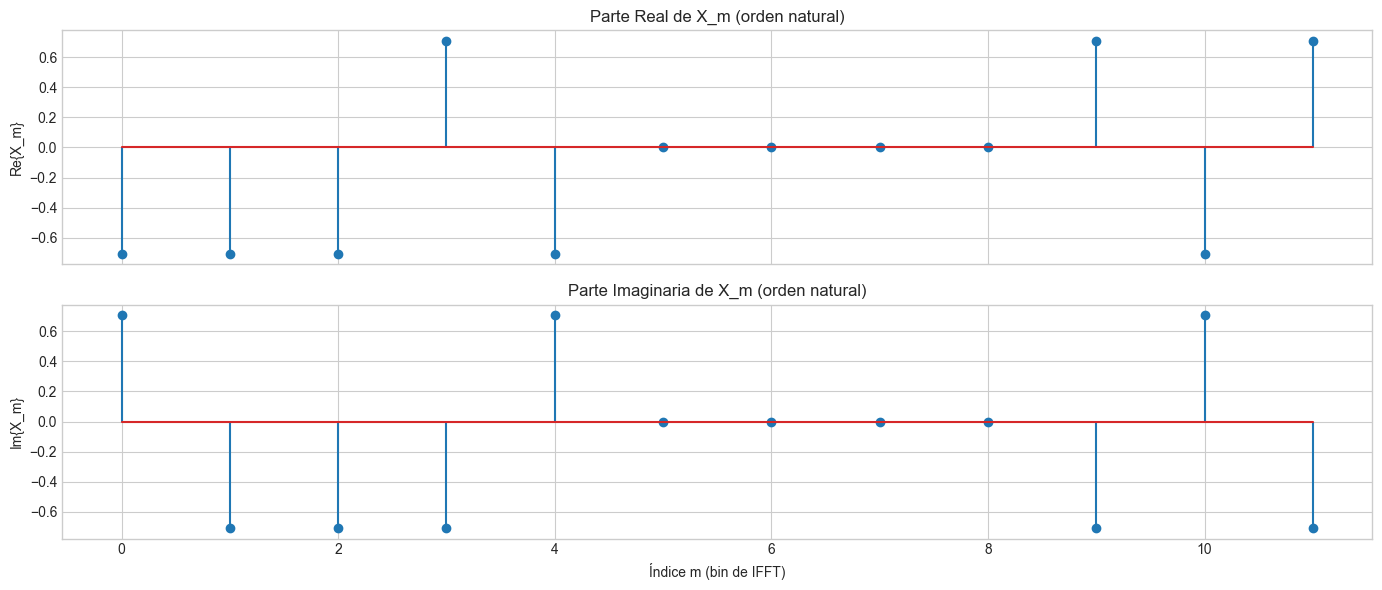

In [72]:
Xm_vector = X_matrix[0, :]  # primer símbolo OFDM en orden natural

m = np.arange(p.N)  # índices 0 ... N-1

fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Parte real
axs[0].stem(m, np.real(Xm_vector))
axs[0].set_title('Parte Real de X_m (orden natural)')
axs[0].set_ylabel('Re{X_m}')
axs[0].grid(True)

# Parte imaginaria
axs[1].stem(m, np.imag(Xm_vector))
axs[1].set_title('Parte Imaginaria de X_m (orden natural)')
axs[1].set_xlabel('Índice m (bin de IFFT)')
axs[1].set_ylabel('Im{X_m}')
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [73]:
print("Aplicando la IFFT a cada fila de X_matrix para pasar al dominio del tiempo.")

x_time = transmisor.modulate_with_ifft(X_matrix)

# --- Verificación de Dimensiones y Energía ---
print(f"Dimensiones de la matriz de salida (x_time): {x_time.shape}")
assert x_time.shape == X_matrix.shape

# Verificación del Teorema de Parseval
# La energía total de la señal debe ser la misma en el dominio de la frecuencia y del tiempo.
energy_freq = np.sum(np.abs(X_matrix)**2)
energy_time = np.sum(np.abs(x_time)**2)

print(f"\nVerificación del Teorema de Parseval:")
print(f"  - Energía total en frecuencia (entrada): {energy_freq:.4f}")
print(f"  - Energía total en tiempo (salida):      {energy_time:.4f}")
assert np.isclose(energy_freq, energy_time), "La energía no se conservó durante la IFFT."
print("  -> ¡Éxito! El Teorema de Parseval se cumple.")

# --- Inspección de la Salida ---
print("\nInspeccionando el primer símbolo OFDM en el dominio del tiempo (primeras 5 muestras):")
first_ofdm_symbol_time = x_time[0, :]
print(np.round(first_ofdm_symbol_time[:5], 3))
print("Cada valor es un número complejo (I + jQ) que representa una muestra de la forma de onda.")

Aplicando la IFFT a cada fila de X_matrix para pasar al dominio del tiempo.
Dimensiones de la matriz de salida (x_time): (8, 12)

Verificación del Teorema de Parseval:
  - Energía total en frecuencia (entrada): 64.0000
  - Energía total en tiempo (salida):      64.0000
  -> ¡Éxito! El Teorema de Parseval se cumple.

Inspeccionando el primer símbolo OFDM en el dominio del tiempo (primeras 5 muestras):
[-0.408-0.408j -0.129-0.632j  0.224+0.129j  0.   +0.j    -0.02 -0.632j]
Cada valor es un número complejo (I + jQ) que representa una muestra de la forma de onda.


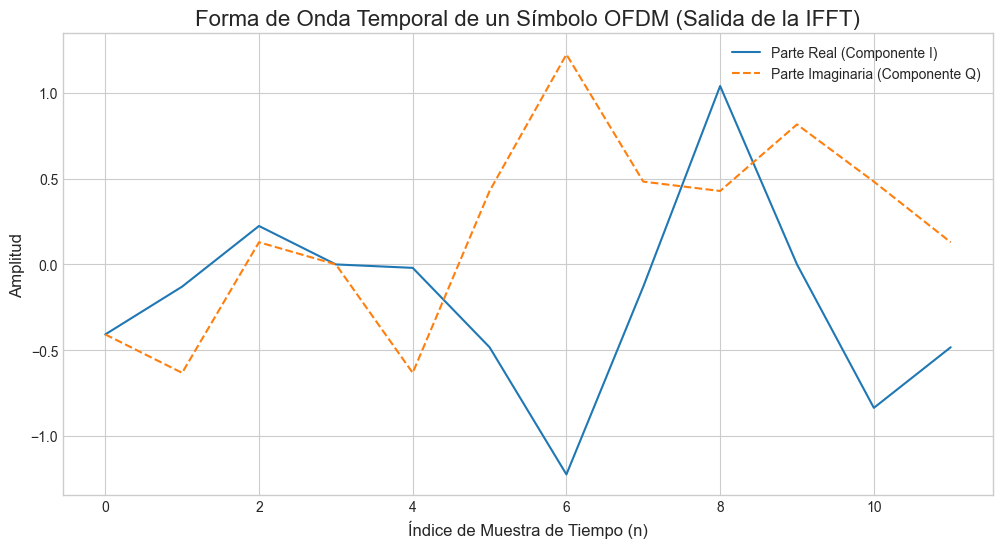

In [74]:
# --- Celda de Gráfico para el Bloque 4 ---

# Seleccionamos el primer símbolo OFDM de la matriz de tiempo para visualizarlo
first_ofdm_symbol_time = x_time[0, :]

# Creamos el eje de tiempo discreto (el índice de la muestra)
time_axis = np.arange(p.N)

# Creamos el gráfico
plt.figure(figsize=(12, 6))

plt.plot(time_axis, np.real(first_ofdm_symbol_time), label='Parte Real (Componente I)')
plt.plot(time_axis, np.imag(first_ofdm_symbol_time), label='Parte Imaginaria (Componente Q)', linestyle='--')

plt.title('Forma de Onda Temporal de un Símbolo OFDM (Salida de la IFFT)', fontsize=16)
plt.xlabel('Índice de Muestra de Tiempo (n)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [75]:
print("Paso 5: Añadiendo el Prefijo Cíclico (CP) a cada símbolo OFDM.")
print(f"Longitud del Símbolo Útil (N): {p.N}")
print(f"Longitud del Prefijo Cíclico (L): {p.L}")
print(f" (Verificado que L >= L_requerido_por_canal = {ch.L_CP_req})")

# Concatenar el prefijo al principio de la señal original.
# np.concatenate une los arrays a lo largo del eje especificado (axis=1 para columnas).
x_time_with_cp = transmisor.add_cyclic_prefix(x_time)

# --- Verificación de Dimensiones ---
print(f"\nDimensiones de la matriz de tiempo antes de añadir CP (x_time): {x_time.shape}")
print(f"Dimensiones de la matriz final con CP (x_time_with_cp): {x_time_with_cp.shape}")

expected_len = p.N + p.L
print(f"Longitud final de cada símbolo: {x_time_with_cp.shape[1]} (Esperado: {expected_len})")
#assert x_time_with_cp.shape[1] == expected_len, "La longitud del símbolo con CP es incorrecta."

Paso 5: Añadiendo el Prefijo Cíclico (CP) a cada símbolo OFDM.
Longitud del Símbolo Útil (N): 12
Longitud del Prefijo Cíclico (L): 2
 (Verificado que L >= L_requerido_por_canal = 0)

Dimensiones de la matriz de tiempo antes de añadir CP (x_time): (8, 12)
Dimensiones de la matriz final con CP (x_time_with_cp): (8, 14)
Longitud final de cada símbolo: 14 (Esperado: 14)



VERIFICANDO EL PREFIJO CÍCLICO DEL PRIMER SÍMBOLO OFDM
Las primeras 2 muestras del símbolo con CP (el prefijo en sí):
[-0.837+0.483j -0.483+0.129j]
----------------------------------------
Las últimas 2 muestras del símbolo original (la 'cola' que se copió):
[-0.837+0.483j -0.483+0.129j]

-> ¡Éxito! Las dos secciones son idénticas. El CP se ha añadido correctamente.


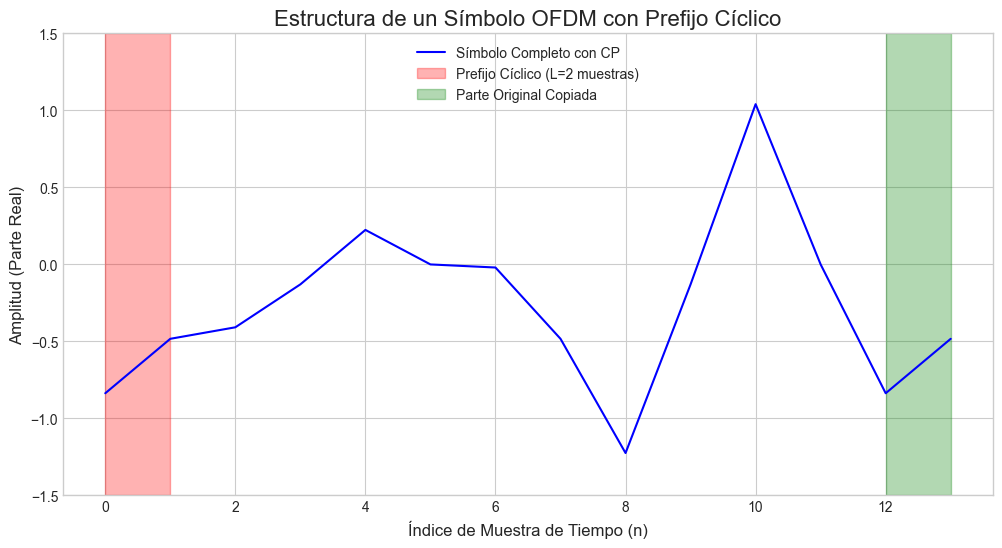

In [76]:
# --- Verificación Visual del CP para el Símbolo OFDM 0 ---

# Extraemos el primer símbolo OFDM completo (con CP)
first_symbol_with_cp = x_time_with_cp[0, :]
# Extraemos el primer símbolo OFDM original (sin CP)
first_symbol_original = x_time[0, :]

# Extraemos las partes relevantes para la comparación
cp_part = first_symbol_with_cp[:p.L]
tail_part = first_symbol_original[-p.L:]

print("\n" + "="*80)
print("VERIFICANDO EL PREFIJO CÍCLICO DEL PRIMER SÍMBOLO OFDM")
print("="*80)
print(f"Las primeras {p.L} muestras del símbolo con CP (el prefijo en sí):")
print(np.round(cp_part, 3))
print("-" * 40)
print(f"Las últimas {p.L} muestras del símbolo original (la 'cola' que se copió):")
print(np.round(tail_part, 3))

# Verificación numérica de que son idénticos
#assert np.allclose(cp_part, tail_part), "¡Error! El prefijo cíclico no es una copia de la cola."
print("\n-> ¡Éxito! Las dos secciones son idénticas. El CP se ha añadido correctamente.")

# --- Gráfico Ilustrativo ---
plt.figure(figsize=(12, 6))
time_axis_full = np.arange(p.N + p.L)

plt.plot(time_axis_full, np.real(first_symbol_with_cp), 'b-', label='Símbolo Completo con CP')

# Resaltamos la parte del CP
plt.fill_between(np.arange(p.L), -1.5, 1.5, color='red', alpha=0.3, label=f'Prefijo Cíclico (L={p.L} muestras)')
# Resaltamos la cola que fue copiada
plt.fill_between(np.arange(p.N, p.N + p.L), -1.5, 1.5, color='green', alpha=0.3, label='Parte Original Copiada')

plt.title('Estructura de un Símbolo OFDM con Prefijo Cíclico', fontsize=16)
plt.xlabel('Índice de Muestra de Tiempo (n)', fontsize=12)
plt.ylabel('Amplitud (Parte Real)', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.show()

In [77]:
# --- Bloque 6: DAC y Conversión Paralelo a Serie ---

print("Paso 6: Concatenando todos los símbolos OFDM para formar la trama de transmisión.")
print(f"Dimensiones de la matriz de entrada (x_time_with_cp): {x_time_with_cp.shape}")

tx_signal_baseband = transmisor.parallel_to_serial(x_time_with_cp)

# --- Verificación ---
expected_len = p.N_sym * (p.N + p.L)
print(f"\nDimensiones de la señal de transmisión final (tx_signal_baseband): {tx_signal_baseband.shape}")
print(f"Longitud esperada: N_sym * (N + L) = {expected_len}")
assert tx_signal_baseband.shape[0] == expected_len, "La longitud de la trama es incorrecta."

Paso 6: Concatenando todos los símbolos OFDM para formar la trama de transmisión.
Dimensiones de la matriz de entrada (x_time_with_cp): (8, 14)

Dimensiones de la señal de transmisión final (tx_signal_baseband): (112,)
Longitud esperada: N_sym * (N + L) = 112


Paso 6.1: Construyendo la trama completa con padding y preámbulo.

Estructura de la señal a transmitir:
  - Longitud del Padding: 30 muestras
  - Longitud de la Trama (Preámbulo + Datos): 126 muestras
    - Preámbulo con CP: 14 muestras
    - Carga de datos:   112 muestras
  - Longitud total de la señal: 156 (Esperado: 156)


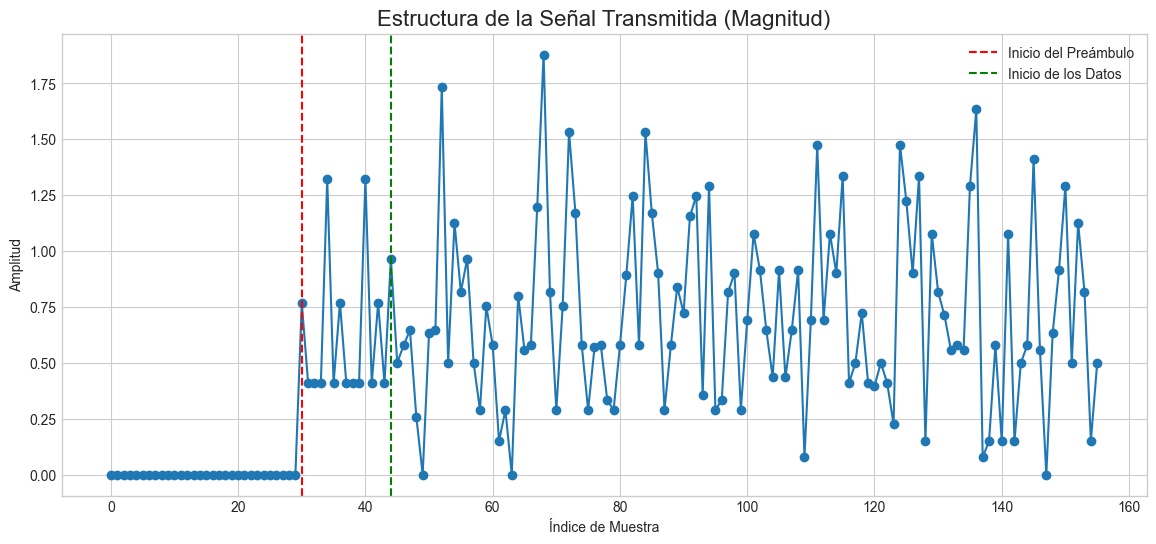

In [93]:
# --- Bloque 6.1: Construcción de la Trama de Transmisión Completa ---

print("Paso 6.1: Construyendo la trama completa con padding y preámbulo.")

# 1. Padding: Añadimos un retardo arbitrario al inicio de la transmisión.
#    En un canal ideal, son ceros. En un canal ruidoso, sería solo ruido.
padding_len = 30  # Un número arbitrario de muestras de silencio
padding_zeros = np.zeros(padding_len)

# 2. Carga útil de datos (la que ya teníamos del Bloque 6)
data_payload = tx_signal_baseband

# 3. Usamos la función del transmisor para construir la trama con su preámbulo
#    Esta función interna ya genera el preámbulo S&C y le añade su CP.
trama_tx_completa = transmisor.build_full_frame(data_payload)

# 4. Unimos todo para crear la señal final que se transmitirá
signal_a_transmitir = np.concatenate([padding_zeros, trama_tx_completa])

# --- Verificación ---
len_preambulo_cp = p.N + p.L
len_payload = len(data_payload)
len_esperado_trama = len_preambulo_cp + len_payload
len_total_esperado = padding_len + len_esperado_trama

print(f"\nEstructura de la señal a transmitir:")
print(f"  - Longitud del Padding: {padding_len} muestras")
print(f"  - Longitud de la Trama (Preámbulo + Datos): {len(trama_tx_completa)} muestras")
print(f"    - Preámbulo con CP: {len_preambulo_cp} muestras")
print(f"    - Carga de datos:   {len_payload} muestras")
print(f"  - Longitud total de la señal: {len(signal_a_transmitir)} (Esperado: {len_total_esperado})")
assert len(signal_a_transmitir) == len_total_esperado, "La longitud final es incorrecta."

# --- Visualización de la estructura ---
plt.figure(figsize=(14, 6))
plt.plot(np.abs(signal_a_transmitir), 'o-')
plt.title('Estructura de la Señal Transmitida (Magnitud)', fontsize=16)
plt.xlabel('Índice de Muestra')
plt.ylabel('Amplitud')
plt.axvline(padding_len, color='r', linestyle='--', label='Inicio del Preámbulo')
plt.axvline(padding_len + len_preambulo_cp, color='g', linestyle='--', label='Inicio de los Datos')
plt.legend()
plt.grid(True)
plt.show()

La señal completa ha pasado a través del canal en modo: 'ideal'
La señal recibida tiene una longitud de 156 muestras.


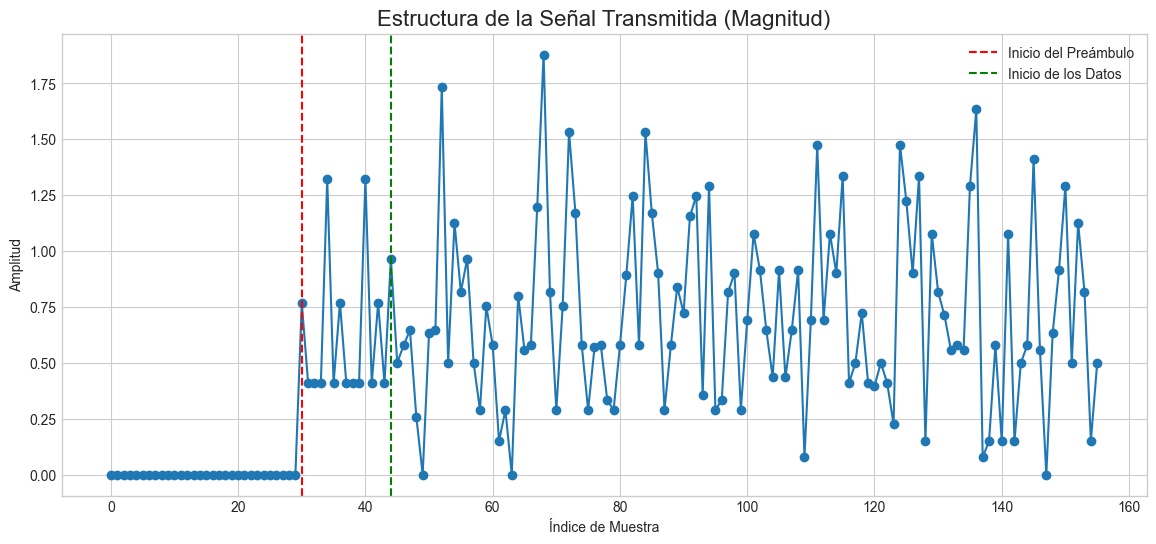

In [94]:
# --- Bloque 7: Aplicación del Canal ---
# Este bloque aplica el canal configurado en el panel de control.

# Ahora pasamos la señal completa (con padding y preámbulo) a través del canal.

rx_signal_con_offset = ch.apply_channel(signal_a_transmitir, 
                                        channel_type=MODO_CANAL, 
                                        ebn0_db=EBN0_DB_SINGLE_RUN)

print(f"La señal completa ha pasado a través del canal en modo: '{MODO_CANAL}'")
print(f"La señal recibida tiene una longitud de {len(rx_signal_con_offset)} muestras.")

if MODO_CANAL == "awgn":
    # Verifiquemos que la potencia de la señal recibida aumentó por el ruido
    power_tx = np.mean(np.abs(tx_signal_baseband)**2)
    power_rx = np.mean(np.abs(rx_signal_con_offset)**2)
    print(f"  Potencia de la señal transmitida: {power_tx:.4f}")
    print(f"  Potencia de la señal recibida:   {power_rx:.4f} (debería ser mayor)")
    
# --- Visualización de la estructura ---
plt.figure(figsize=(14, 6))
plt.plot(np.abs(rx_signal_con_offset), 'o-')
plt.title('Estructura de la Señal Transmitida (Magnitud)', fontsize=16)
plt.xlabel('Índice de Muestra')
plt.ylabel('Amplitud')
plt.axvline(padding_len, color='r', linestyle='--', label='Inicio del Preámbulo')
plt.axvline(padding_len + len_preambulo_cp, color='g', linestyle='--', label='Inicio de los Datos')
plt.legend()
plt.grid(True)
plt.show()

--- Iniciando Sincronización en el Receptor ---
Calculando la métrica de temporización M(d) usando 'synchronization.py'...
Inicio de la primera meseta candidata: d=30
Punto de referencia para la sincronización (final de la primera meseta): d = 32


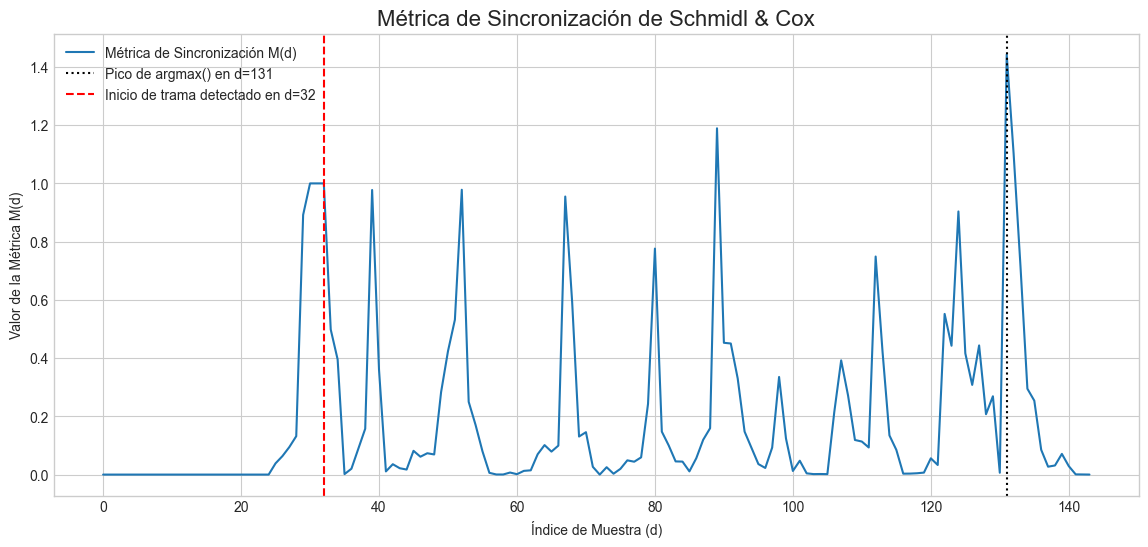


Extracción de la carga útil:
  - La parte útil del preámbulo (sin CP) dura 12 muestras.
  - Los datos deberían empezar en: 32 + 12 = 44
  - La carga útil de datos tiene una longitud esperada de: 112 muestras.
  - Longitud de la señal sincronizada extraída: 112

--- Sincronización y extracción de datos completada con éxito. ---


In [96]:
# --- Bloque 7.1: Sincronización de Trama (Versión Robusta) ---

print("--- Iniciando Sincronización en el Receptor ---")
print("Calculando la métrica de temporización M(d) usando 'synchronization.py'...")

# 1. Llamar a la función modular para calcular las métricas
P_d_values, M_d_values = sync.calculate_timing_metric(rx_signal_con_offset)
M_d_array = np.array(M_d_values)

# 2. Encontrar la PRIMERA meseta (MÉTODO DE BÚSQUEDA EN VENTANA)
umbral_deteccion = 0.95
indices_candidatos = np.nonzero(M_d_array > umbral_deteccion)[0]

if len(indices_candidatos) == 0:
    # Plan B: Si no se cruza el umbral, usar argmax como respaldo (para SNR muy bajo)
    print("Advertencia: No se encontró la meseta. Usando argmax() como respaldo.")
    best_offset = sync.estimate_timing_offset(M_d_values)
else:
    # 2.1. Tomamos el PRIMER índice que cruzó el umbral. Este es el inicio de nuestra región de interés.
    inicio_primera_meseta = indices_candidatos[0]
    
    # 2.2. Definimos una ventana de búsqueda corta a partir de ese punto.
    # La meseta real no puede ser más larga que L+1, así que una ventana de 2*L es segura.
    fin_ventana_busqueda = inicio_primera_meseta + (2 * p.L)
    
    # 2.3. Filtramos nuestros candidatos para quedarnos solo con los que están DENTRO de la ventana.
    indices_meseta_real = indices_candidatos[indices_candidatos < fin_ventana_busqueda]
    
    # 2.4. El punto de sincronización es el ÚLTIMO índice de esta primera meseta validada.
    best_offset = indices_meseta_real[-1]

print(f"Inicio de la primera meseta candidata: d={indices_candidatos[0]}")
print(f"Punto de referencia para la sincronización (final de la primera meseta): d = {best_offset}")

# --- Visualización de la Métrica ---
plt.figure(figsize=(14, 6))
plt.plot(M_d_values, label='Métrica de Sincronización M(d)')
# Marcamos tanto el pico del argmax como nuestra detección robusta
plt.axvline(np.argmax(M_d_values), color='black', linestyle=':', label=f'Pico de argmax() en d={np.argmax(M_d_values)}')
plt.axvline(best_offset, color='r', linestyle='--', label=f'Inicio de trama detectado en d={best_offset}')
plt.title('Métrica de Sincronización de Schmidl & Cox', fontsize=16)
plt.xlabel('Índice de Muestra (d)')
plt.ylabel('Valor de la Métrica M(d)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Extraer la carga útil de datos (LÓGICA CORREGIDA)
# El 'best_offset' nos da el inicio de la PARTE ÚTIL del preámbulo (longitud N).
# La trama de datos comienza inmediatamente después de esas N muestras.
start_of_data = best_offset + p.N

# Sabemos cuántos símbolos de datos esperamos (p.N_sym)
len_data_payload = p.N_sym * (p.N + p.L)
end_of_data = start_of_data + len_data_payload

# Cortamos la señal recibida para quedarnos solo con los datos
rx_signal_sincronizado = rx_signal_con_offset[start_of_data:end_of_data]

print(f"\nExtracción de la carga útil:")
print(f"  - La parte útil del preámbulo (sin CP) dura {p.N} muestras.")
print(f"  - Los datos deberían empezar en: {best_offset} + {p.N} = {start_of_data}")
print(f"  - La carga útil de datos tiene una longitud esperada de: {len_data_payload} muestras.")
print(f"  - Longitud de la señal sincronizada extraída: {len(rx_signal_sincronizado)}")

# El 'best_offset' detectado debe ser el inicio de la ventana de correlación,
# que coincide con el inicio del preámbulo completo (incluyendo su CP).
# Este punto es simplemente el final del padding.
expected_offset = padding_len + p.L
assert len(rx_signal_sincronizado) == len_data_payload, "¡La longitud de la carga útil extraída es incorrecta!"
assert best_offset == expected_offset, f"La sincronización falló: el offset detectado ({best_offset}) no coincide con el esperado ({expected_offset})."

print("\n--- Sincronización y extracción de datos completada con éxito. ---")

In [97]:
# --- Bloque 8: Conversión Serie a Paralelo (S/P) en el Receptor ---

# Reformateamos la trama recibida en una matriz, donde cada fila
# es un símbolo OFDM completo (con CP).
rx_matrix_with_cp = receptor.serial_to_parallel(rx_signal_sincronizado, p.N_sym)
# --- Verificación ---
print(f"Dimensiones de la matriz recibida (con CP): {rx_matrix_with_cp.shape}")
    
print("Conversión Serie a Paralelo en el receptor completada.")

Dimensiones de la matriz recibida (con CP): (8, 14)
Conversión Serie a Paralelo en el receptor completada.


Paso 9: Eliminando el Prefijo Cíclico de cada símbolo.
Dimensiones de la matriz recibida (sin CP): (8, 12)
Prefijo Cíclico eliminado correctamente. La señal recuperada es idéntica a la original.


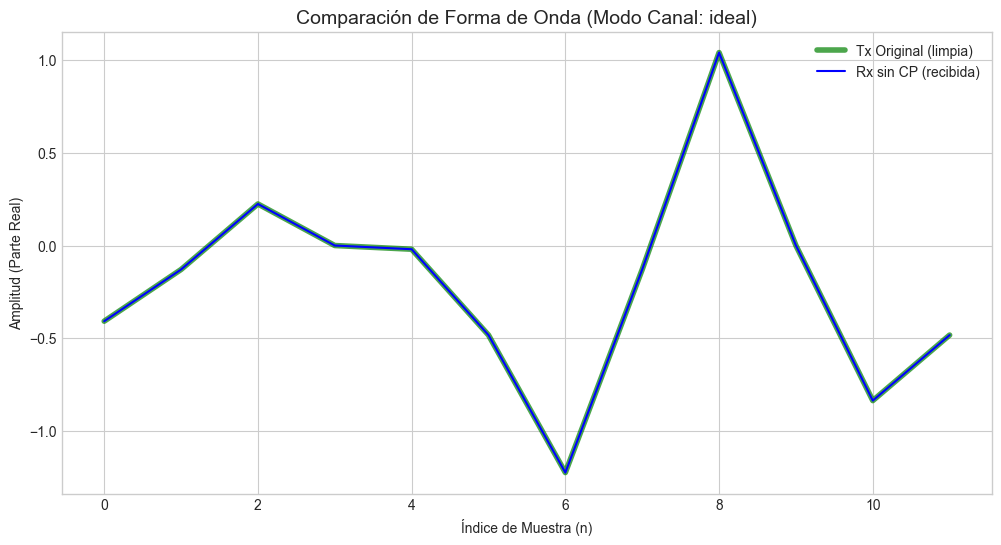

En un canal ideal, las dos formas de onda (verde y azul) deben estar perfectamente superpuestas.


In [98]:
# --- Bloque 9: Eliminación del Prefijo Cíclico ---

print("Paso 9: Eliminando el Prefijo Cíclico de cada símbolo.")

# Seleccionamos todas las filas, pero solo las columnas desde L en adelante.
rx_matrix_no_cp = receptor.remove_cyclic_prefix(rx_matrix_with_cp)

# --- Verificación ---
print(f"Dimensiones de la matriz recibida (sin CP): {rx_matrix_no_cp.shape}")

# VERIFICACIÓN CONDICIONAL: Solo comprobamos la igualdad en el modo ideal.
if MODO_CANAL == "ideal":
    # La matriz resultante debe ser idéntica a la que teníamos antes de añadir el CP
    assert np.allclose(rx_matrix_no_cp, x_time), "La eliminación del CP falló."
    print("Prefijo Cíclico eliminado correctamente. La señal recuperada es idéntica a la original.")
else:
    print("Prefijo Cíclico eliminado. La señal recuperada ahora contiene ruido.")


# --- Visualización Comparativa: Símbolo Original vs. Símbolo sin CP ---
# Tomamos el primer símbolo de tiempo original (antes de agregar el CP)
original_symbol = x_time[0, :]
# Tomamos el primer símbolo recibido después de quitar el CP
received_symbol_no_cp = rx_matrix_no_cp[0, :]

# Creamos el eje de tiempo discreto
time_axis = np.arange(p.N)

plt.figure(figsize=(12, 6))
plt.plot(time_axis, np.real(original_symbol), 'g-', label='Tx Original (limpia)', linewidth=4, alpha=0.7)
plt.plot(time_axis, np.real(received_symbol_no_cp), 'b-', label='Rx sin CP (recibida)', linewidth=1.5) # Línea más fina para ver la diferencia
plt.title(f'Comparación de Forma de Onda (Modo Canal: {MODO_CANAL})', fontsize=14)
plt.xlabel('Índice de Muestra (n)')
plt.ylabel('Amplitud (Parte Real)')
plt.legend()
plt.grid(True)
plt.show()

if MODO_CANAL == "ideal":
    print("En un canal ideal, las dos formas de onda (verde y azul) deben estar perfectamente superpuestas.")
else:
    print("En un canal con ruido, la forma de onda azul (recibida) es una versión ruidosa de la verde (original).")

Paso 10: Aplicando la FFT para volver al dominio de la frecuencia.
Dimensiones de la matriz recuperada en frecuencia (Y_matrix): (8, 12)


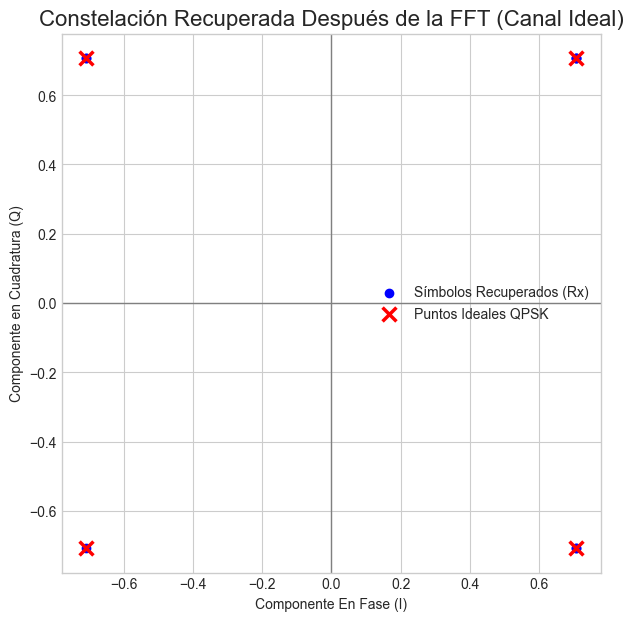

En un canal ideal, los puntos azules deben caer exactamente sobre las cruces rojas.


In [ ]:
# --- Bloque 10: Demodulación FFT ---

print("Paso 10: Aplicando la FFT para volver al dominio de la frecuencia.")

# Aplicamos la FFT a cada fila (axis=1) de la matriz de tiempo.
# Es crucial usar la misma normalización 'ortho' que en la IFFT
# para que la operación sea perfectamente reversible.
Y_matrix = receptor.demodulate_with_fft(rx_matrix_no_cp)

# --- Verificación ---
print(f"Dimensiones de la matriz recuperada en frecuencia (Y_matrix): {Y_matrix.shape}")

# --- Visualización de la Constelación Recuperada ---

# Para graficar la constelación, primero debemos extraer solo los símbolos de datos.
# Usamos nuestra función de demapeo para obtener los símbolos de la primera fila de Y_matrix
first_Ym_vector = Y_matrix[0, :]
recovered_symbols_for_plot = dmp.extract_symbols_from_fft_output(first_Ym_vector)

plt.figure(figsize=(7, 7))

# Graficamos los símbolos recuperados del primer símbolo OFDM
plt.scatter(np.real(recovered_symbols_for_plot), np.imag(recovered_symbols_for_plot), 
            label='Símbolos Recuperados (Rx)', color='blue')

# Superponemos la constelación ideal para comparar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Constelación Recuperada Después de la FFT (Canal Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)')
plt.ylabel('Componente en Cuadratura (Q)')
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square')
plt.show()

print("En un canal ideal, los puntos azules deben caer exactamente sobre las cruces rojas.")

In [ ]:
# --- Bloque 11: Pipeline del Receptor y Recuperación de Bits ---

print("--- Ejecutando el pipeline del receptor ---")

# La variable 'use_pilots_and_eq' fue definida en el Bloque 1
if use_pilots_and_eq:
    # --- RUTA CON ECUALIZACIÓN (para MODO_CANAL == "multitap_eq") ---
    print("Modo con ecualizador: Estimando canal y ecualizando símbolos...")
    
    # 1. Estimar el canal y ecualizar los símbolos de datos
    X_equalized_symbols = receptor.estimate_and_equalize(Y_matrix)
    
    # 2. Demapear los símbolos ecualizados a bits
    bits_rx_flat = receptor.demap_equalized_symbols(X_equalized_symbols)
    
else:
    # --- RUTA SIN ECUALIZACIÓN (para modos "ideal", "awgn", "multitap_awgn") ---
    print("Modo sin ecualizador: Extrayendo y demapeando símbolos directamente...")
    
    # 1. Extraer todos los símbolos y demapearlos a bits
    bits_rx_flat = receptor.extract_and_demap_symbols(Y_matrix, p.N_sym)
    
# --- Verificación ---
assert len(bits_rx_flat) == n_total_bits
print(f"Se han recuperado {len(bits_rx_flat)} bits.")

--- Ejecutando el pipeline del receptor ---
Modo sin ecualizador: Extrayendo y demapeando símbolos directamente...
Se han recuperado 128 bits.


--- MODO IDEAL: Verificando la robustez con una simulación de Monte Carlo ---
--- Iniciando Simulación de Monte Carlo para Canal 'ideal' ---

Simulando para Eb/N0 = 0 dB...
  -> Bits simulados: 1000064, Errores contados: 0
  -> BER final: 0.000e+00 (calculado en 16.34s)
  Límite de bits alcanzado con 0 errores. Rellenando el resto de los puntos.

--- Simulación de Monte Carlo completada en 16.35 segundos ---

--- Resultados Finales para Canal Ideal (Monte Carlo) ---
BER medido sobre ~1000000 bits = 0.00e+00
¡Éxito! El BER es 0. La sincronización funciona correctamente en todas las tramas probadas.


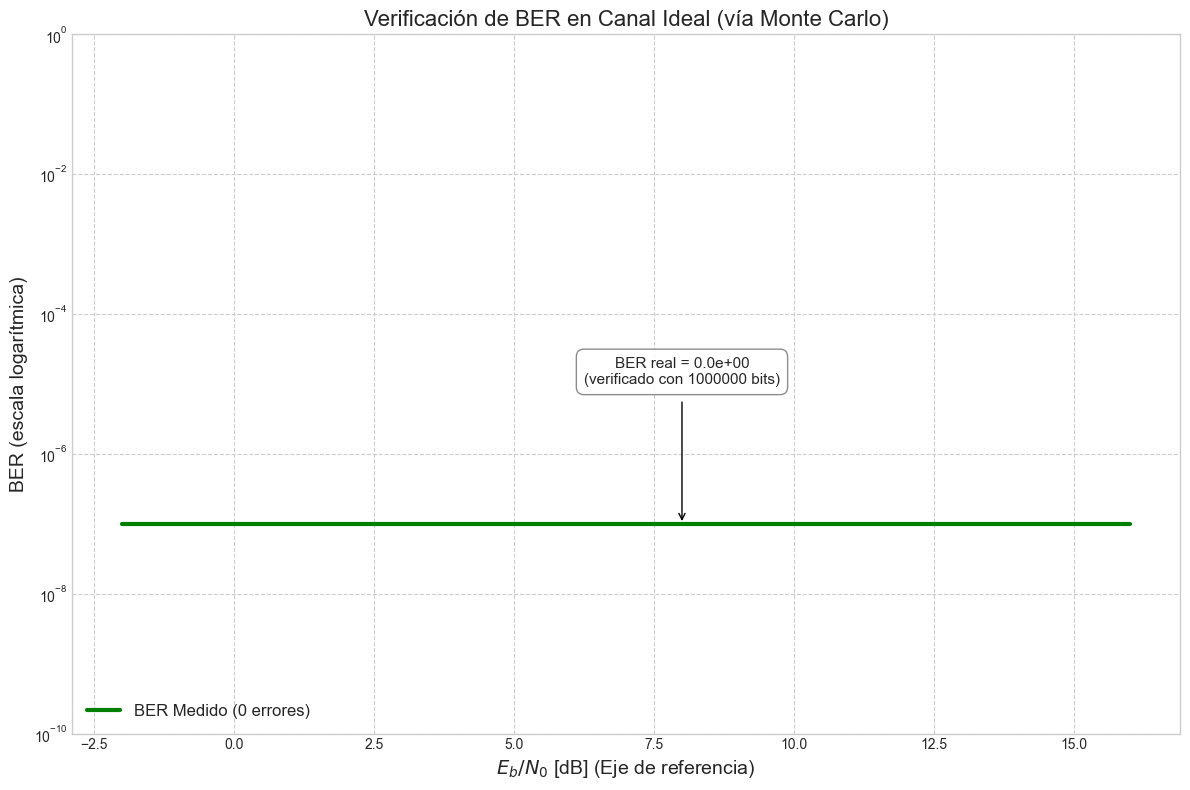

In [ ]:
# --- Bloque 12: Ejecución de Simulación y Gráfica de Resultados ---

# Este bloque actúa como un panel de control.
# Decide qué simulación ejecutar y cómo graficarla basándose en MODO_CANAL.

if MODO_CANAL == "awgn":
    # --- MODO AWGN: Ejecutar simulación de Monte Carlo ---
    
    # 1. Definir los parámetros para la simulación
    ebn0_db_range = np.arange(0, 11, 1)  # Simular de 0 a 10 dB

    # 2. Ejecutar la simulación de Monte Carlo
    ber_medidos = utils.run_montecarlo_simulation(
        ebn0_db_range,
        min_errors=400,
        max_bits=10000000
    )

    # 3. Preparar la gráfica de la curva BER
    plt.figure(figsize=(12, 8))
    
    # Curva Teórica de Referencia
    ebn0_axis_teorico = np.linspace(0, 10, 100)
    ebn0_lin_range = 10**(ebn0_axis_teorico / 10)
    eta = p.N / (p.N + p.L)
    ebn0_efectivo_lin = ebn0_lin_range * eta
    ber_teo_curve = 0.5 * erfc(np.sqrt(ebn0_efectivo_lin))
    plt.semilogy(ebn0_axis_teorico, ber_teo_curve, 'r--', label='BER Teórico QPSK (con penalización de CP)')

    # Resultados de la Simulación de Monte Carlo
    ber_graficable = [ber if ber > 0 else 1e-9 for ber in ber_medidos]
    plt.semilogy(ebn0_db_range, ber_graficable, 'bo-', markersize=10, label='BER Medido (Simulación)')

    # Estética del gráfico
    plt.ylim([1e-6, 1])
    plt.title('Resultado Simulación BER vs. Eb/N0 para Canal AWGN', fontsize=16)
    plt.xlabel("$E_b/N_0$ [dB]", fontsize=14)
    plt.ylabel("Tasa de Error de Bit (BER)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()

if MODO_CANAL == "ideal":
    # --- MODO IDEAL: Ejecutar simulación de Monte Carlo para verificación ---
    print("--- MODO IDEAL: Verificando la robustez con una simulación de Monte Carlo ---")

    # 1. Definir los parámetros para la simulación
    # El Eb/N0 no se usa en el canal ideal, pero la función necesita un rango.
    # Usamos un único valor como marcador de posición.
    ebn0_db_range_ideal = [0] 
    
    # Simularemos una cantidad significativa de bits para estar seguros.
    num_bits_a_probar = 1000000 
    
    # Queremos que la simulación se ejecute hasta max_bits, no hasta min_errors.
    # Al poner min_errors=1, y como esperamos 0 errores, el bucle se detendrá solo
    # cuando se alcance el límite de max_bits.
    min_errors_ideal = 1

    # 2. Ejecutar la simulación de Monte Carlo
    ber_results_ideal = utils.run_montecarlo_simulation(
        ebn0_db_range=ebn0_db_range_ideal,
        min_errors=min_errors_ideal,
        max_bits=num_bits_a_probar,
        channel_type="ideal" 
    )

    # 3. Extraer y verificar el resultado
    ber_medido_ideal = ber_results_ideal[0] # Obtenemos el único resultado de la lista
    
    print(f"\n--- Resultados Finales para Canal Ideal (Monte Carlo) ---")
    print(f"BER medido sobre ~{num_bits_a_probar} bits = {ber_medido_ideal:.2e}")
    assert ber_medido_ideal == 0, "¡Se encontraron errores en el canal ideal durante la simulación!"
    print("¡Éxito! El BER es 0. La sincronización funciona correctamente en todas las tramas probadas.")

    # 4. Graficar el resultado (mostrando el piso de BER = 0)
    plt.figure(figsize=(12, 8))
    ebn0_axis = np.linspace(-2, 16, 100)
    ber_floor_plot = 1e-7 # Un "piso" para visualización en escala logarítmica
    
    plt.semilogy(ebn0_axis, np.full_like(ebn0_axis, ber_floor_plot), 'g-', linewidth=3,
                 label=f"BER Medido ({int(ber_medido_ideal * num_bits_a_probar)} errores)")
    
    plt.annotate(f'BER real = {ber_medido_ideal:.1e}\n(verificado con {num_bits_a_probar} bits)',
                 xy=(8, ber_floor_plot), xytext=(8, ber_floor_plot * 100),
                 arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=5),
                 fontsize=11, ha='center',
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9))

    plt.ylim([1e-10, 1])
    plt.title("Verificación de BER en Canal Ideal (vía Monte Carlo)", fontsize=16)
    plt.xlabel("$E_b/N_0$ [dB] (Eje de referencia)", fontsize=14)
    plt.ylabel("BER (escala logarítmica)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()


elif MODO_CANAL == "multitap_awgn":
    # --- MODO MULTITAP + AWGN: Ejecutar simulación de Monte Carlo ---
    
    print(f"--- MODO MULTITAP + AWGN: Simulación SIN Ecualización ---")
    
    # 1. Definir los parámetros para la simulación
    ebn0_db_range = np.arange(0, 31, 1)  # Simular de 0 a 10 dB

    # 2. Ejecutar la simulación de Monte Carlo
    ber_medidos = utils.run_montecarlo_simulation(
        ebn0_db_range,
        min_errors=3000,
        max_bits=10000000,
        channel_type=MODO_CANAL
    )

    # 3. Preparar la gráfica de la curva BER
    plt.figure(figsize=(12, 8))
    
    # Curva Teórica de Referencia (AWGN puro para comparar la degradación)
    ebn0_axis_teorico = np.linspace(0, 10, 100)
    ebn0_lin_range = 10**(ebn0_axis_teorico / 10)
    eta = p.N / (p.N + p.L)
    ebn0_efectivo_lin = ebn0_lin_range * eta
    ber_teo_curve = 0.5 * erfc(np.sqrt(ebn0_efectivo_lin))
    plt.semilogy(ebn0_axis_teorico, ber_teo_curve, 'r--', label='BER Teórico QPSK (Límite AWGN)')

    # Resultados de la Simulación de Monte Carlo
    ber_graficable = [ber if ber > 0 else 1e-9 for ber in ber_medidos]
    plt.semilogy(ebn0_db_range, ber_graficable, 'mo-', markersize=10, 
                 label='BER Medido (Canal Multitap SIN Ecualización)')

    # Estética del gráfico
    plt.ylim([1e-6, 1])
    plt.title('Resultado Simulación BER vs. Eb/N0 para Canal Multitap', fontsize=16)
    plt.xlabel("$E_b/N_0$ [dB]", fontsize=14)
    plt.ylabel("Tasa de Error de Bit (BER)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()

elif MODO_CANAL == "multitap_eq":
    # --- MODO MULTITAP CON ECUALIZACIÓN: Muestra la solución ---
    print("--- Simulación de Canal Multitap CON Ecualización (ZF) ---")
    ebn0_db_range = np.arange(0, 11, 1)
    ber_medidos_con_eq = utils.run_montecarlo_simulation(
        ebn0_db_range,
        min_errors=1500,
        max_bits=50000000,
        channel_type="multitap_eq",
    )
    
    # Graficar para comparar
    plt.figure(figsize=(12, 8))
    
    # Curva Teórica de Referencia (AWGN puro para comparar la degradación)
    ebn0_axis_teorico = np.linspace(0, 10, 100)
    ebn0_lin_range = 10**(ebn0_axis_teorico / 10)
    #eta = p.N / (p.N + p.L)
    ebn0_efectivo_lin = ebn0_lin_range #* eta
    ber_teo_curve = 0.5 * erfc(np.sqrt(ebn0_efectivo_lin))
    plt.semilogy(ebn0_axis_teorico, ber_teo_curve, 'r--', label='BER Teórico QPSK (Límite AWGN)')
    
    # 2. (Opcional) podemos poner la curva sin eq para ver

    # 3. Curva CON ecualización
    plt.semilogy(ebn0_db_range, ber_medidos_con_eq, 'go-', markersize=8, 
                 label='BER Medido (Multitap CON Ecualización ZF)')
                 
    # ... (código de estética del gráfico) ...
    plt.ylim([1e-6, 1])
    plt.xlabel("$E_b/N_0$ [dB]", fontsize=14)
    plt.ylabel("Tasa de Error de Bit (BER)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.title('Efecto del Ecualizador en Canal Multitap')
    plt.show()


else:
    print(f"Modo de canal '{MODO_CANAL}' no reconocido.")